In [ ]:
import pandas as pd
import numpy as np

# Thư viện để xử lý mất cân bằng dữ liệu
from sklearn.utils import resample

# Thư viện chia tập dữ liệu và tiền xử lý văn bản
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Thư viện mô hình và đánh giá
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import re

In [ ]:
!pip install pyvi
from pyvi import ViTokenizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.1 MB/s eta 0:00:00


## 1. Đọc và Tiền xử lý dữ liệu

In [ ]:
df_raw = pd.read_excel("/content/data_prepared.xlsx")
df_tf = df_raw.copy()

In [ ]:
LABEL_NAMES = {
    0: "Bình thường",
    1: "Ít nghiêm trọng",
    2: "Nghiêm trọng",
    3: "Rất nghiêm trọng",
}

def assign_label(rating: int) -> int:
    if rating == 1:   return 3
    elif rating == 2: return 2
    elif rating == 3: return 1
    else:             return 0    # 4, 5 sao

df_tf["label"] = df_tf["Rating"].apply(assign_label)

print("Phân phối nhãn:")
print(df_tf["label"].map(LABEL_NAMES).value_counts().to_string())

Phân phối nhãn:
label
Bình thường         70256
Rất nghiêm trọng     3750
Ít nghiêm trọng       342
Nghiêm trọng          288


In [ ]:

# Chuyển đổi Rating (1-5 sao) thành các nhãn (label) cụ thể
df_tf["label"] = df_tf["Rating"].apply(assign_label)

# Loại bỏ các dòng trống hoặc bị lỗi sau khi xử lý
df_tf = df_tf[df_tf["text_clean"].str.len() > 0]
df_tf = df_tf.dropna(subset=["text_clean", "label"]).reset_index(drop=True)

## 2. Xử lý mất cân bằng dữ liệu (Resampling)

In [ ]:
#Xử lý imbalance cho TF-IDF
TARGET_TF = 1000
parts_df_tf  = []
for lbl in range(4):
    sub = df_tf[df_tf["label"] == lbl]
    parts_df_tf.append(resample(sub, n_samples=TARGET_TF,
                              replace=len(sub) < TARGET_TF, random_state=42))
df_tf_bal = pd.concat(parts_df_tf).sample(frac=1, random_state=42)

## 3. Chia tập Train và Test

In [ ]:
X_tf = df_tf_bal["text_clean"]
y_tf = df_tf_bal["label"]

# Chia tập Train / Test split
X_tf_train, X_tf_test, y_tf_train, y_tf_test = train_test_split(
    X_tf, y_tf, test_size=0.2, random_state=42, stratify=y_tf
)

## 4. Biến đổi văn bản thành số (TF-IDF)

In [ ]:
tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2))
X_tf_train_v = tfidf.fit_transform(X_tf_train)
X_tf_test_v  = tfidf.transform(X_tf_test)

## 5. Huấn luyện mô hình Logistic Regression

In [ ]:
tf_model = LogisticRegression(
    max_iter=1000, class_weight="balanced", C=1.0, random_state=42
)
tf_model.fit(X_tf_train_v, y_tf_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 6. Dự đoán và Đánh giá

In [ ]:
tf_pred = tf_model.predict(X_tf_test_v)

TARGET_NAMES = list(LABEL_NAMES.values())
print("LOGISTIC REGRESSION + TF-IDF")
print(classification_report(y_tf_test, tf_pred, target_names=TARGET_NAMES))

LOGISTIC REGRESSION + TF-IDF
                  precision    recall  f1-score   support

     Bình thường       0.77      0.85      0.81       200
 Ít nghiêm trọng       0.83      0.72      0.77       200
    Nghiêm trọng       0.84      0.84      0.84       200
Rất nghiêm trọng       0.74      0.76      0.75       200

        accuracy                           0.79       800
       macro avg       0.79      0.79      0.79       800
    weighted avg       0.79      0.79      0.79       800



## 7. Kết quả

In [ ]:
# Dự đoán trên toàn bộ tập dữ liệu
X_full_tfidf = tfidf.transform(df_tf["text_clean"].fillna(''))
full_lr_preds = tf_model.predict(X_full_tfidf)

# Tổng hợp kết quả vào DataFrame
df_tfidf_results = df_tf.copy()
df_tfidf_results["predicted_label"]      = full_lr_preds
df_tfidf_results["predicted_label_name"] = df_tfidf_results["predicted_label"].map(LABEL_NAMES)

# Lọc và Sắp xếp dữ liệu
OUTPUT_COLS_TFIDF = [
    "User", "Rating", "Review", "Date",
    "text_clean", "label", "predicted_label", "predicted_label_name",
]
df_tfidf_results_sorted = df_tfidf_results[OUTPUT_COLS_TFIDF].sort_values(by='Date', ascending=False)

df_tfidf_results_sorted.to_excel("zalopay_tfidf_results.xlsx", index=False)
print("Đã lưu → zalopay_tfidf_results.xlsx")
display(df_tfidf_results_sorted.head())

Đã lưu → zalopay_tfidf_results.xlsx


,User,Rating,Review,Date,text_clean,label,predicted_label,predicted_label_name
0,Ngọc Trần,5,oke,2026-06-01 12:49:02,ổn,0,0,Bình thường
1,Mê game Wuang,5,Tuy là hơi lằng nhằng mà lúc sau thì ngon,2026-06-01 12:19:12,Tuy là hơi lằng nhằng mà lúc sau thì ngon,0,1,Ít nghiêm trọng
2,Tổng tài Lạnh lùng,1,"thủ tục lằng nhằng, có cái đổi sdt xét 2 ngày ...",2026-06-01 12:15:02,"thủ tục lằng nhằng, có cái đổi số điện thoại x...",3,3,Rất nghiêm trọng
3,Nhung Hồng,1,như Iồn,2026-06-01 12:09:40,như Iồn,3,2,Nghiêm trọng
4,Uhg Yhjjjf,4,đm giờ bắt liên kết ngân hàng,2026-06-01 12:01:39,đm giờ bắt liên kết ngân hàng,0,1,Ít nghiêm trọng


## 8. Vẽ ma trận


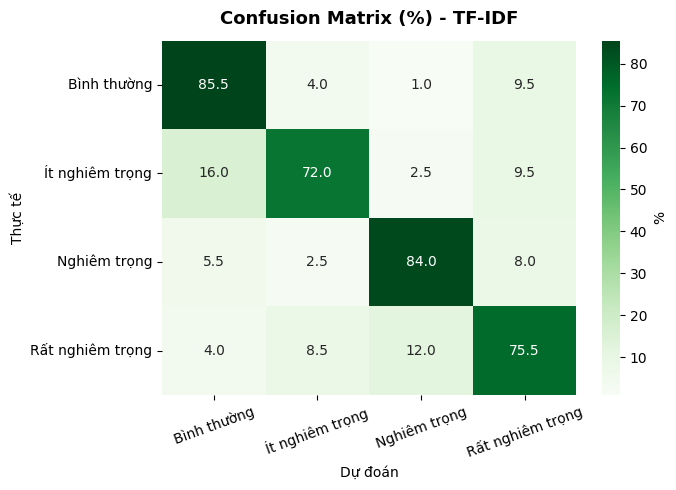

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Biểu đồ: Confusion Matrix (%) cho TF-IDF
fig, ax = plt.subplots(figsize=(7, 5))

cm     = confusion_matrix(y_tf_test, tf_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Greens",
    xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
    cbar_kws={"label": "%"}, ax=ax,
)
ax.set_title("Confusion Matrix (%) - TF-IDF", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Dự đoán")
ax.set_ylabel("Thực tế")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score

idf_f1 = f1_score(y_tf_test, tf_pred, average="macro")
print(f"TF-IDF F1 Macro: {idf_f1:.4f}")

TF-IDF F1 Macro: 0.7921
